In [5]:
cd res/

/Users/leo/Documents/github/physics-of-agents/res


In [6]:
# Trajectory archetypes from data/clean_runs.json: individual trajectories
# (per-agent flip classes) and group trajectories (per-society band classes).
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

from utils import (MODELS, REGIMES, TAU, IND_CLASSES, GRP_CLASSES, load_data,
                   opinions, flip_counts, individual_archetypes, group_archetypes)

runs, banks, P, GCLASS = load_data()

# Compute each run's mean opinion \bar{o}_i
for r in runs:
    # opinions: Computes the mean opinion of each agent over the last 5 rounds of the simulation.
    r["opinions"] = opinions(r)  # (9 rounds, 32 agents), k=5-resample means
print(len(runs), "societies")

9604 societies


In [7]:
matches = [
    (i, r)
    for i, r in enumerate(runs)
    if r.get("statement") == "Student loan debt should be forgiven by the government"
    and r.get("model") == "gemini-3.5-flash-lite"
]

print("Matches:", len(matches))

for i, r in matches:
    print(i, r.get("model"), r.get("mode"), r.get("statement"))

Matches: 1
0 gemini-3.5-flash-lite subjective Student loan debt should be forgiven by the government


In [8]:
r = runs[0]

print("Statement:", r["statement"])
print("\nPersonas:")
for i, p in enumerate(r.get("personas", [])):
    print(f"Agent {i}: {p}")

print("\nJ:")
for row in r["J"]:
    print(row)

print("\nOpinion history:")
for t, spins in enumerate(r["spins_history"]):
    print(f"Round {t}: {spins}")

Statement: Student loan debt should be forgiven by the government

Personas:

J:
[0, 0, 0, -1]
[0, 0, -1, 0]
[0, -1, 0, 1]
[-1, 0, 1, 0]

Opinion history:
Round 0: [1, -1, 1, -1]
Round 1: [1, -1, 1, 1]
Round 2: [1, -1, 1, -1]


In [9]:
from pathlib import Path
import json

model = r["model"]
regime = r["mode"]

manifest_path = (
    Path("../data/models")
    / model
    / f"{regime}_energy"
    / "manifest.json"
)

print(manifest_path)
print(manifest_path.exists())

with open(manifest_path, "r", encoding="utf-8") as f:
    manifest = json.load(f)

print(manifest.keys())

reps = manifest.get("replicas", {}).values()

example_question = next(iter(reps))

reps

../data/models/gemini-3.5-flash-lite/subjective_energy/manifest.json
True
dict_keys(['meta', 'replicas'])


dict_values([{'qid': 'political_stance_0', 'split': 'train', 'question': 'Student loan debt should be forgiven by the government', 'graph_id': 'J0', 'graph_seen': True, 'repeat': 0, 'num_edges': 6}, {'qid': 'political_stance_156', 'split': 'test', 'question': 'Financial transaction taxes would reduce market volatility', 'graph_id': 'J0', 'graph_seen': True, 'repeat': 0, 'num_edges': 6}])

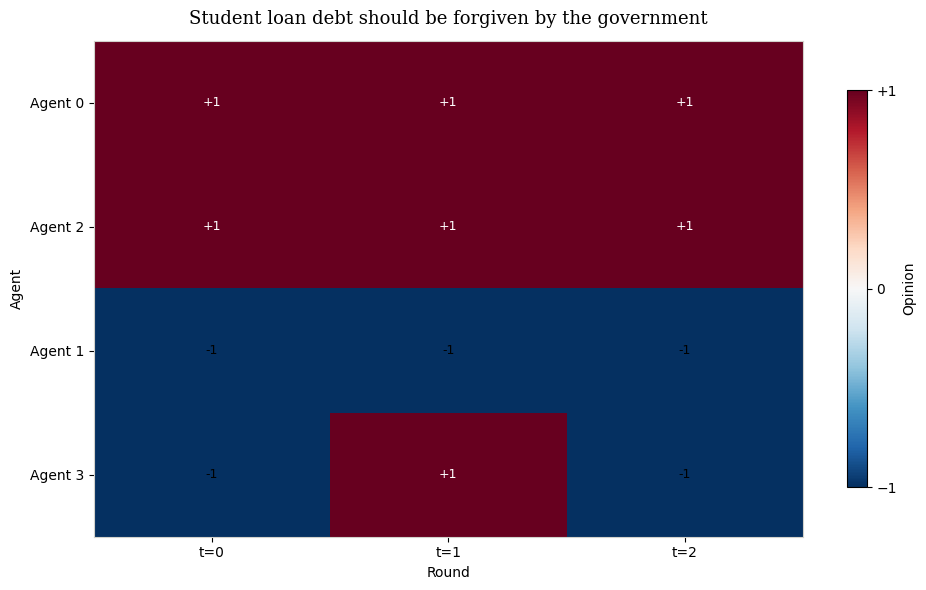

In [10]:
import numpy as np
import matplotlib.pyplot as plt

opinions = np.asarray(r["spins_history"])

# opinions shape: (rounds, agents)
T, N = opinions.shape

fig, ax = plt.subplots(figsize=(10, 6))

# Sort agents by their final opinion
order = np.argsort(-opinions[-1])

# Agents x rounds
data = opinions.T[order]

im = ax.imshow(
    data,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    aspect="auto",
    interpolation="nearest"
)

# X axis
ax.set_xticks(
    range(T),
    [f"t={t}" for t in range(T)]
)

# Y axis
ax.set_yticks(
    range(N),
    [f"Agent {i}" for i in order]
)

ax.set_xlabel("Round")
ax.set_ylabel("Agent")

ax.set_title(
    r["statement"],
    fontsize=13,
    family="serif",
    pad=12
)

# Add values inside cells
for i in range(N):
    for t in range(T):
        value = data[i, t]

        if value > 0:
            text_color = "white"
        else:
            text_color = "black"

        ax.text(
            t,
            i,
            f"{value:+.0f}",
            ha="center",
            va="center",
            fontsize=9,
            color=text_color
        )

# Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Opinion")

cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(["−1", "0", "+1"])

# Borders
for s in ax.spines.values():
    s.set_color("#d2d2cc")

plt.tight_layout()
plt.show()

In [11]:
pwd

'/Users/leo/Documents/github/physics-of-agents/res'

In [12]:
# Retrieve messages from example run 

import json
from pathlib import Path

def get_messages(model, regime, qid, graph, rep, data_dir="../data/models"):
    file = (
        Path(data_dir)
        / model
        / f"{regime}_energy"
        / f"{qid}__{graph}__rep{rep:02d}.json"
    )

    print(file)

    with open(file, "r", encoding="utf-8") as f:
        raw = json.load(f)

    return raw.get("messages_history", [])

In [13]:
qid = example_question["qid"]
graph = example_question["graph_id"]

messages = get_messages(
    model=r["model"],
    regime=r["mode"],
    qid=example_question["qid"],
    graph=example_question["graph_id"],
    rep=example_question["repeat"]
)

print("\nMessages:")

for t, round_messages in enumerate(messages):
    print(f"\n--- Round {t} ---")

    for sender_receiver, message in round_messages.items():
        print(sender_receiver, ":", message)

../data/models/gemini-3.5-flash-lite/subjective_energy/political_stance_0__J0__rep00.json

Messages:

--- Round 0 ---
0,3 : Honestly, I think the government really needs to step in and cancel student loan debt so people can finally get some breathing room. It just makes sense to give folks a fair shot at moving forward without being weighed down by monthly payments forever.
1,2 : I just don't think it's fair to the people who were responsible and paid off their own bills without any handouts. Plus, wiping out all that debt overnight would mess with the economy and doesn't fix the actual reason college costs so much in the first place.
2,1 : Honestly, wiping out student loan debt just makes sense for leveling the playing field and getting things moving again. People shouldn't be chained to a bad financial deal forever just for trying to get an education.
2,3 : Honestly, wiping out student loan debt just makes sense for leveling the playing field and getting things moving again. People s